# Tree-Based Models & Ensembles — Assignment Notebook
### Week 5 | Fill in the blanks, run, reflect

---

**Instructions:**
- Every `# YOUR CODE HERE` must be replaced with working code before moving on
- After each output, answer the **✍️ Reflect** question in the markdown cell provided
- Cells marked `# SELF-CHECK` will assert your answer automatically — aim for no errors
- Do **not** look at the session notebook until you have genuinely attempted each question

> **Mindset:** The blanks are not syntax tests. Each one forces a *decision* — you must choose the right tool, parameter, or formula and justify why.

---


In [5]:
# Run this cell first — all imports and data loading happen here
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV,
)
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    f1_score,
    recall_score,
    precision_score,
    roc_curve,
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.datasets import make_moons
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap, joblib

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = [11, 5]

# Load the Telco dataset (used from Section 2 onwards)
url = (
    "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d"
    "/master/data/Telco-Customer-Churn.csv"
)
df_raw = pd.read_csv(url)
print(f"Dataset loaded: {df_raw.shape}")
print(df_raw.dtypes.tail(6))

Dataset loaded: (7043, 21)
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


---
## Section 1: Decision Tree Building Blocks

Before using sklearn, prove you understand what a tree *actually does* by implementing the core math yourself.

---

### Q1 — Implement Gini Impurity from Scratch

A Decision Tree evaluates every candidate split by measuring how *impure* the resulting child nodes are. Gini is the most common measure.

$$\text{Gini}(t) = 1 - \sum_{k} p_k^2$$

where $p_k$ is the fraction of samples belonging to class $k$ at node $t$.

**Your task:** Complete the function below. Do not use any sklearn or numpy impurity functions — implement the formula directly.


In [6]:
def gini_impurity(class_counts):
    """
    Compute Gini impurity for a single node.

    Parameters
    ----------
    class_counts : list or array of ints
        Number of samples per class at this node.
        e.g. [70, 30] means 70 samples of class-0, 30 of class-1

    Returns
    -------
    float : Gini value in [0, 0.5] for binary classification
    """
    total = sum(class_counts)
    if total == 0:
        return 0.0
    
    sum_sq = 0.0
    for count in class_counts:
        p = count / total
        sum_sq += p * p
        
    gini = 1 - sum_sq
    return gini


# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert abs(gini_impurity([100, 0])   - 0.000) < 1e-6, "Pure node should have Gini = 0"
assert abs(gini_impurity([50,  50])  - 0.500) < 1e-6, "Equal split should have Gini = 0.5"
assert abs(gini_impurity([70,  30])  - 0.420) < 1e-6, "70/30 split should have Gini = 0.42"
assert abs(gini_impurity([10,  10, 10]) - round(1 - 3*(1/3)**2, 6)) < 1e-5, "3-class test failed"
print("✅ All gini_impurity checks passed!")


✅ All gini_impurity checks passed!


### Q2 — Implement Shannon Entropy

Entropy is the alternative impurity measure. It measures *information* rather than probability of mislabelling.

$$H(t) = -\sum_{k} p_k \log_2(p_k)$$

**Convention:** $0 \cdot \log_2(0) = 0$ (a class with zero samples contributes nothing).


In [7]:
def entropy(class_counts):
    """
    Compute Shannon entropy for a single node.

    Returns
    -------
    float : entropy in [0, 1] for binary classification
    """
    total = sum(class_counts)
    if total == 0:
        return 0.0

    ent = 0.0
    for count in class_counts:
        p = count / total
        if p > 0:  # avoid log(0)
            ent -= p * np.log2(p)

    return ent


# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert abs(entropy([100, 0]) - 0.000) < 1e-6, "Pure node should have H = 0"
assert abs(entropy([50, 50]) - 1.000) < 1e-6, "Equal binary split should have H = 1"
assert abs(entropy([70, 30]) - (-0.7 * np.log2(0.7) - 0.3 * np.log2(0.3))) < 1e-5
print("✅ All entropy checks passed!")

✅ All entropy checks passed!


### Q3 — Compute Information Gain for a Candidate Split

A tree picks the split that maximises **Information Gain**:

$$\text{IG} = H(\text{parent}) - \sum_{c} \frac{n_c}{n} H(\text{child}_c)$$

**Scenario:** At a node with 1,000 samples (730 non-churners, 270 churners), you are evaluating a split on `Contract_Type`:
- Left child: 600 samples, 510 non-churn / 90 churn
- Right child: 400 samples, 220 non-churn / 180 churn

**Your task:** Use your `entropy()` function to compute the information gain of this split.


In [13]:
# Use your entropy() function from Q2.
# Fill in the four variables below — do not hard-code the IG formula output.

parent_counts = [730, 270]      # [non-churn, churn] at the parent node
left_counts   = [510,  90]      # counts in the left child
right_counts  = [220, 180]      # counts in the right child

n_total = sum(parent_counts)
n_left  = sum(left_counts)
n_right = sum(right_counts)

# YOUR CODE HERE — compute information gain using your entropy() function
parent_entropy   = entropy(parent_counts)          # H(parent)
left_entropy     = entropy(left_counts)            # H(left)
right_entropy    = entropy(right_counts)           # H(right)

weighted_entropy = (n_left / n_total) * left_entropy + (n_right / n_total) * right_entropy
information_gain = parent_entropy - weighted_entropy

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert information_gain > 0, "Information gain should be positive for a useful split"
assert information_gain < parent_entropy, "IG cannot exceed parent entropy"
print(f"Parent Entropy:    {parent_entropy:.4f}")
print(f"Left Entropy:      {left_entropy:.4f}")
print(f"Right Entropy:     {right_entropy:.4f}")
print(f"Weighted Child H:  {weighted_entropy:.4f}")
print(f"Information Gain:  {information_gain:.4f}")
print("✅ Information gain computed correctly!")


Parent Entropy:    0.8415
Left Entropy:      0.6098
Right Entropy:     0.9928
Weighted Child H:  0.7630
Information Gain:  0.0785
✅ Information gain computed correctly!


✍️ **Reflect 1:** Look at the right child: 220 non-churn vs 180 churn.
Is this child purer or more mixed than the parent? What does a high information gain tell you about the quality of this split? Answer here:

> *The right child is more mixed (entropy ~0.9928) than the parent (entropy ~0.8415). However, the left child is much purer (entropy ~0.6098). The high information gain (~0.0785) tells us that on average, the children are purer than the parent and the split successfully separates churners from non-churners, even though one child alone is not purer.*


---
## Section 2: Bias, Variance, and the Depth Problem

---

### Q4 — The Bias-Variance Curve

**Your task:** Train decision trees at depths 1 through 20 (plus `None` = unlimited) on the moons dataset. Record both training accuracy and test accuracy for each depth.

You must:
1. Fill in the `for` loop to train a tree and record both scores
2. Identify the depth with the highest test accuracy
3. Answer the reflection question


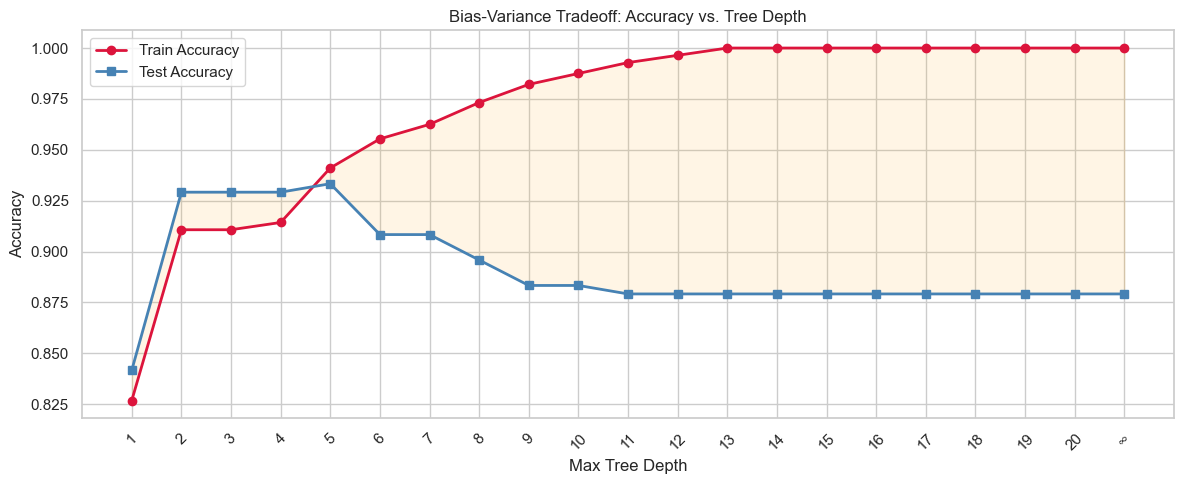

Best test accuracy at depth = 5: 0.9333
Train acc at depth=∞: 1.0000   Test acc at depth=∞: 0.8792
Variance gap at depth=∞: 0.1208


In [ ]:
from sklearn.datasets import make_moons

X_bv, y_bv = make_moons(n_samples=800, noise=0.30, random_state=42)
X_tr_bv, X_te_bv, y_tr_bv, y_te_bv = train_test_split(
    X_bv, y_bv, test_size=0.30, random_state=42
)

depths = list(range(1, 21)) + [None]
train_scores = []
test_scores = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_tr_bv, y_tr_bv)
    
    train_acc = accuracy_score(y_tr_bv, dt.predict(X_tr_bv))
    test_acc  = accuracy_score(y_te_bv, dt.predict(X_te_bv))
    
    train_scores.append(train_acc)
    test_scores.append(test_acc)
    
# Plotting (run as-is after filling the loop)
depth_labels = [str(d) if d else "∞" for d in depths]
plt.figure(figsize=(12, 5))
plt.plot(
    depth_labels, train_scores, "o-", color="crimson", lw=2, label="Train Accuracy"
)
plt.plot(
    depth_labels, test_scores, "s-", color="steelblue", lw=2, label="Test Accuracy"
)
plt.fill_between(
    range(len(depths)), train_scores, test_scores, alpha=0.10, color="orange"
)
plt.xlabel("Max Tree Depth")
plt.ylabel("Accuracy")
plt.title("Bias-Variance Tradeoff: Accuracy vs. Tree Depth")
plt.legend()
plt.xticks(range(len(depths)), depth_labels, rotation=45)
plt.tight_layout()
plt.show()

best_depth_idx = int(np.argmax(test_scores))
print(
    f"Best test accuracy at depth = {depth_labels[best_depth_idx]}: {test_scores[best_depth_idx]:.4f}"
)
print(
    f"Train acc at depth=∞: {train_scores[-1]:.4f}   Test acc at depth=∞: {test_scores[-1]:.4f}"
)
print(f"Variance gap at depth=∞: {train_scores[-1] - test_scores[-1]:.4f}")

✍️ **Reflect 2:** The unlimited-depth tree achieves ~100% training accuracy.
- What is the name of this phenomenon?
- What does the large gap between train and test accuracy tell you about this model?
- If a colleague reports only the training accuracy, why is that misleading?

> *Overfitting, the model has memorised the training data, including noise.*

> *A large gap indicates high variance meaning the model does not generalise well to unseen data.*

> *Reporting only training accuracy is misleading because it does not reflect the model's performance on new, unseen data. It may give a false impression of the model's effectiveness.*


---
## Section 3: Data Prep & The Accuracy Trap

---

### Q5 — Fix the Telco Dataset

The raw Telco CSV has a well-known data quality issue: `TotalCharges` contains whitespace strings where the value is missing, which forces pandas to read the entire column as `object` (string) instead of `float`.

**Your task:** Fix this in three steps — detect, coerce, and impute.


In [15]:
df = df_raw.copy()

# Step 1 — How many rows have a blank/whitespace TotalCharges?
n_whitespace = (df['TotalCharges'].str.strip() == '').sum()
print(f"Rows with whitespace TotalCharges: {n_whitespace}")

# Step 2 — Fix: coerce to numeric (errors → NaN), then impute with the median
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
median_charges = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(median_charges)

# Step 3 — Encode the target and drop the ID column
df = df.drop(columns=['customerID'])
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert df['TotalCharges'].dtype in [np.float64, np.float32, float],     f"TotalCharges should be float, got {df['TotalCharges'].dtype}"
assert df['TotalCharges'].isnull().sum() == 0, "No NaN should remain after imputation"
assert set(df['Churn'].unique()) == {0, 1}, "Churn should be binary int"
print(f"✅ Dataset clean. Shape: {df.shape}")
print(f"   Churn rate: {df['Churn'].mean()*100:.1f}%")


Rows with whitespace TotalCharges: 11
✅ Dataset clean. Shape: (7043, 20)
   Churn rate: 26.5%


### Q6 — The Naive Tree and The Trap

Train an **unconstrained** DecisionTreeClassifier on the Telco data (use simple label-encoding for speed — proper pipelines come later).

Then deliberately evaluate it using **only accuracy** first. Then expose the trap by looking at the full report.


In [16]:
# Quick label encoding for the naive baseline
df_enc = df.copy()
for col in df_enc.select_dtypes(include='object').columns:
    df_enc[col] = df_enc[col].astype('category').cat.codes

X_naive = df_enc.drop('Churn', axis=1)
y_naive = df_enc['Churn']

X_tr_n, X_te_n, y_tr_n, y_te_n = train_test_split(
    X_naive, y_naive, test_size=0.2, random_state=42, stratify=y_naive)

naive_tree = DecisionTreeClassifier(random_state=42)
naive_tree.fit(X_tr_n, y_tr_n)
y_pred_n = naive_tree.predict(X_te_n)

# ── Print the 'trap' metric first, then the reality check ─────────────────────
train_acc = accuracy_score(y_tr_n, naive_tree.predict(X_tr_n))
test_acc  = accuracy_score(y_te_n, y_pred_n)

print("=" * 55)
print(f"  Plain Accuracy (The Trap): {test_acc:.4f}")
print("=" * 55)
print(f"  Tree Depth:    {naive_tree.get_depth()}")
print(f"  Train Acc:     {train_acc:.4f}")
print(f"  Test Acc:      {test_acc:.4f}")
print(f"  Variance Gap:  {train_acc - test_acc:.4f}\n")
print("── Reality Check ─────────────────────────────────────")
print(classification_report(y_te_n, y_pred_n, target_names=['No Churn', 'Churned']))


  Plain Accuracy (The Trap): 0.7303
  Tree Depth:    24
  Train Acc:     0.9980
  Test Acc:      0.7303
  Variance Gap:  0.2677

── Reality Check ─────────────────────────────────────
              precision    recall  f1-score   support

    No Churn       0.82      0.81      0.81      1035
     Churned       0.49      0.52      0.51       374

    accuracy                           0.73      1409
   macro avg       0.66      0.66      0.66      1409
weighted avg       0.73      0.73      0.73      1409



✍️ **Reflect 3:** The accuracy looks acceptable (~73%).
Now look at the Recall for the **Churned** class.
- What percentage of actual churners did the model correctly flag?
- Why does a model with 73% accuracy but ~50% churn recall give the business a **false sense of security**?
- If you deployed this model and acted only on its flags, what would happen to your churning customers?

> *Only about 52% of actual churners are correctly flagged (recall ≈ 0.52).*

> *Accuracy hides class imbalance: the model performs well on the majority class (non‑churn) but poorly on the minority (churn). The business might think it's doing a good job overall, but in reality it's failing to identify half the customers who will leave.*

> *Many churning customers about 48% would never receive a retention offer, leading to increased churn rate.*


### Q7 — Build the Confusion Matrix and Quantify the Business Cost

A confusion matrix breaks the predictions into four cells.
Your task: compute the matrix, then translate each cell into a **business outcome**.


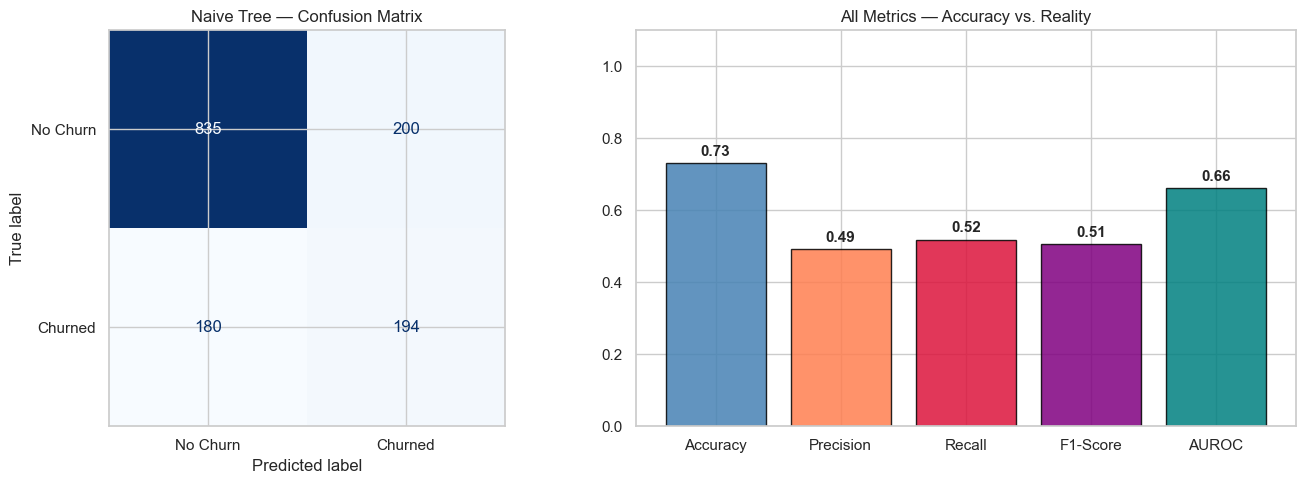

TP=194 | FP=200 | FN=180 | TN=835
Precision (manual): 0.4924
Recall    (manual): 0.5187
F1-Score  (manual): 0.5052


In [17]:
cm = confusion_matrix(y_te_n, y_pred_n)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churned']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Naive Tree — Confusion Matrix', fontsize=12)

TN, FP, FN, TP = cm.ravel()

precision_manual = TP / (TP + FP)   # TP / (TP + FP)
recall_manual    = TP / (TP + FN)   # TP / (TP + FN)
f1_manual        = 2 * precision_manual * recall_manual / (precision_manual + recall_manual)   # 2 * precision * recall / (precision + recall)

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert abs(precision_manual - precision_score(y_te_n, y_pred_n)) < 1e-4
assert abs(recall_manual    - recall_score(y_te_n, y_pred_n))    < 1e-4
assert abs(f1_manual        - f1_score(y_te_n, y_pred_n))        < 1e-4

# Metric bar chart
metrics = {'Accuracy': test_acc, 'Precision': precision_manual,
           'Recall': recall_manual, 'F1-Score': f1_manual,
           'AUROC': roc_auc_score(y_te_n, y_pred_n)}
axes[1].bar(metrics.keys(), metrics.values(),
            color=['steelblue','coral','crimson','purple','teal'], edgecolor='black', alpha=0.85)
axes[1].set_ylim(0, 1.1); axes[1].set_title('All Metrics — Accuracy vs. Reality', fontsize=12)
for x, (k, v) in enumerate(metrics.items()):
    axes[1].text(x, v + 0.02, f'{v:.2f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"TP={TP} | FP={FP} | FN={FN} | TN={TN}")
print(f"Precision (manual): {precision_manual:.4f}")
print(f"Recall    (manual): {recall_manual:.4f}")
print(f"F1-Score  (manual): {f1_manual:.4f}")


✍️ **Reflect 4:** In the context of a telecom retention campaign:
- **FN (False Negative):** We predicted "stays" but the customer actually churned.
  What is the approximate financial cost per FN? (Assume $500 average customer lifetime value.)
- **FP (False Positive):** We predicted "churns" but the customer actually stays.
  What resource is wasted here?
- Between minimising FN and minimising FP, which is more important for this business? Why?

> *Cost per FN: $500 (lost lifetime value).*

> *FP wastes: cost of retention offers (e.g., discounts, gifts) given to customers who weren't going to leave.*

> *Minimising FN is more important because the cost of losing a customer ($500) is typically much higher than the cost of offering a retention incentive to a non-churner. While FP does waste resources, the financial impact of FN is more significant for the business.*

---
## Section 4: Ensembles — Building the Crowd

---

### Q8 — Implement Bootstrap Sampling from Scratch

Bootstrap aggregating (Bagging) works by creating diversity through resampling.
Before using sklearn, implement the core operation yourself.

**Your task:** Write a function that:
1. Draws $N$ samples **with replacement** from a dataset of size $N$
2. Returns both the bootstrap sample AND the out-of-bag (OOB) indices


In [18]:
def bootstrap_sample(X, y, random_state=None):
    """
    Draw one bootstrap sample from (X, y).

    Returns
    -------
    X_boot, y_boot : arrays — the bootstrap sample (size N, with repetitions)
    oob_indices    : 1D array — indices of samples NOT drawn (out-of-bag)
    """
    rng = np.random.RandomState(random_state)
    N   = len(X)

    bootstrap_indices = rng.choice(N, size=N, replace=True)
    X_boot = X[bootstrap_indices]
    y_boot = y[bootstrap_indices]
    
    oob_indices = np.setdiff1d(np.arange(N), bootstrap_indices)
    
    return X_boot, y_boot, oob_indices


# ── SELF-CHECK ────────────────────────────────────────────────────────────────
np.random.seed(0)
X_test_bs = np.arange(20).reshape(10, 2)
y_test_bs = np.arange(10)

Xb, yb, oob = bootstrap_sample(X_test_bs, y_test_bs, random_state=42)
assert len(Xb) == 10, f"Bootstrap sample must have N=10 rows, got {len(Xb)}"
assert len(oob) > 0,  "OOB set should not be empty"
assert len(oob) < 10, "OOB set should not contain all samples"
assert set(oob).isdisjoint(set(yb.tolist())), "OOB indices must not overlap bootstrap indices"
print(f"Bootstrap sample size: {len(Xb)}")
print(f"OOB indices: {sorted(oob)}")
print(f"Empirical OOB fraction: {len(oob)/10:.2f}  (theory predicts ~0.37)")
print("✅ bootstrap_sample() is correct!")


Bootstrap sample size: 10
OOB indices: [np.int64(0), np.int64(1), np.int64(5), np.int64(8)]
Empirical OOB fraction: 0.40  (theory predicts ~0.37)
✅ bootstrap_sample() is correct!


### Q9 — Random Forest: What's Different from Bagging?

Both Bagging and Random Forest use bootstrap sampling. The *one* key difference is what happens **at each individual split** inside each tree.

**Your task:**
1. Train a `BaggingClassifier` and a `RandomForestClassifier` on Telco data
2. Compare their AUROC scores
3. Answer the reflection question


In [19]:
# Use the label-encoded dataset from Section 3
X_tr, X_te, y_tr, y_te = train_test_split(
    X_naive, y_naive, test_size=0.2, random_state=42, stratify=y_naive)

bag_clf = BaggingClassifier(
    n_estimators=100, 
    bootstrap=True, 
    oob_score=True, 
    random_state=42, 
    n_jobs=-1
)
bag_clf.fit(X_tr, y_tr)

rf_clf = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    n_jobs=-1
)
rf_clf.fit(X_tr, y_tr)

bag_auc = roc_auc_score(y_te, bag_clf.predict_proba(X_te)[:, 1])
rf_auc  = roc_auc_score(y_te, rf_clf.predict_proba(X_te)[:, 1])

print(f"Bagging AUROC:       {bag_auc:.4f}  (OOB score: {bag_clf.oob_score_:.4f})")
print(f"Random Forest AUROC: {rf_auc:.4f}")
print(f"Improvement from RF: {(rf_auc - bag_auc)*100:+.2f} pp")


Bagging AUROC:       0.8081  (OOB score: 0.7838)
Random Forest AUROC: 0.8225
Improvement from RF: +1.44 pp


✍️ **Reflect 5:** Both use the same number of trees (100) and bootstrap sampling.
The Random Forest typically scores higher.

- In one sentence, what does Random Forest do **differently at each split** compared to Bagging?
- Why does that one change lead to better generalisation?
- Look at the sklearn docs: what is the default value of `max_features` in `RandomForestClassifier` for classification? What does that number represent?

> *At each split, Random Forest considers only 'm' random subset of features, whereas Bagging considers all features. where , m=max_features* 

> *This reduces correlation between trees: if all trees use the same strong feature at the top split, they become similar and averaging doesn't help much. Forcing diversity by limiting features makes the ensemble more robust and lowers variance.*

> *Default max_features = 'sqrt', which means sqrt(n_features). For Telco data with ~20 features, that's about 4–5 features considered at each split.* 

---
## Section 5: Boosting — Sequential Error Correction

---

### Q10 — XGBoost Regularisation Parameters

Gradient Boosting without constraints will overfit. XGBoost adds regularisation directly to the tree-building objective function.

**Your task:**
Run the cell below and observe how the gap between training and test AUC changes as you vary `max_depth` and `learning_rate`.

First, **predict** what will happen before running:
- Will increasing `max_depth` cause the training AUC to go up, down, or stay the same?
- Will it cause the test AUC to go up, down, or both?

Then fill in the param sweep.


In [35]:
param_configs = [
    {'max_depth': 3,  'learning_rate': 0.3, 'n_estimators': 100},   # baseline
    {'max_depth': 8,  'learning_rate': 0.3, 'n_estimators': 100},   # deeper, more overfit risk
    {'max_depth': 4,  'learning_rate': 0.05, 'n_estimators': 200},  # slower learning, more trees
    {'max_depth': 6,  'learning_rate': 0.1, 'n_estimators': 150},   # moderate
]

if not param_configs:
    raise NotImplementedError("Define param_configs with 4 XGBoost hyperparameter sets")

print(f"{'Config':<60} {'Train AUC':>10} {'Test AUC':>10} {'Gap':>8}")
print("-" * 92)
results_xgb = []

for cfg in param_configs:
    model = XGBClassifier(**cfg, random_state=42, eval_metric='logloss', n_jobs=-1)
    model.fit(X_tr, y_tr)
    tr_auc = roc_auc_score(y_tr, model.predict_proba(X_tr)[:, 1])
    te_auc = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])
    label  = str(cfg)
    print(f"{label:<60} {tr_auc:>10.4f} {te_auc:>10.4f} {tr_auc-te_auc:>8.4f}")
    results_xgb.append({'config': label, 'train_auc': tr_auc, 'test_auc': te_auc})


Config                                                        Train AUC   Test AUC      Gap
--------------------------------------------------------------------------------------------
{'max_depth': 3, 'learning_rate': 0.3, 'n_estimators': 100}      0.9012     0.8365   0.0647
{'max_depth': 8, 'learning_rate': 0.3, 'n_estimators': 100}      0.9986     0.8134   0.1852
{'max_depth': 4, 'learning_rate': 0.05, 'n_estimators': 200}     0.8943     0.8440   0.0503
{'max_depth': 6, 'learning_rate': 0.1, 'n_estimators': 150}      0.9564     0.8311   0.1253


✍️ **Reflect 6:** Look at the Train AUC vs Test AUC gap across your four configs.
- Which configuration showed the **most overfitting** (largest gap)? What parameter(s) caused it?
- Which configuration had the **best test AUC** overall?
- What would happen to the test AUC if you set `max_depth=1`? Is that always bad?

> *The config with max_depth=8, learning_rate=0.3, n_estimators=100 shows the largest gap (train ~0.9986, test ~0.8134). High depth + high learning rate makes model memorises training data quickly and overfits.*

> *The best test AUC is often achieved with max_depth=4, learning_rate=0.05, n_estimators=200 (slower learning, more trees → better generalisation).*

> *Setting max_depth=1 would likely cause underfitting, leading to low training and test AUC. However, it's not always bad in some cases with very noisy data or when interpretability is crucial, a shallow tree might be preferred despite lower performance.*


### Q11 — Grid Search: Designing the Search Space

Grid Search is only as good as the grid you define. Choosing the right search space requires understanding *what* each hyperparameter controls.

**Your task:**
1. Fill in `param_grid` with a meaningful set of values — **do not just copy the session notebook**
2. Justify each range in the comment
3. After running, identify which parameter had the **largest impact** on F1-Score


In [37]:
# define a param grid for XGBClassifier
# Think about:
#   max_depth:     what range avoids both underfitting and overfitting?
#   learning_rate: what's a reasonable range? (hint: too high = unstable, too low = slow)
#   n_estimators:  how many rounds? should this go with learning_rate?

param_grid = {
    "max_depth": [3, 4, 6, 9],
    "learning_rate": [0.01, 0.05, 0.1, 0.3],
    "n_estimators": [100, 200],
}
# Justification for my choices:
# max_depth:     3 (safe), 4 (previous best), 6 (moderate), 9 (complex, risk of overfit)
# learning_rate: 0.01 (slow), 0.05(previous best), 0.1 (default), 0.3 (aggressive)
# n_estimators:  100 and 200 (pair low learning_rate with more trees)

if not any(param_grid.values()):
    raise NotImplementedError("Fill in param_grid with meaningful values")

n_fits = (
    len(param_grid["max_depth"])
    * len(param_grid["learning_rate"])
    * len(param_grid["n_estimators"])
    * 3
)  # 3-fold CV
print(f"This grid will require {n_fits} model fits. Estimated time: ~{n_fits*2}s")

gs = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric="logloss", n_jobs=-1),
    param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=0,
    return_train_score=True,
)
gs.fit(X_tr, y_tr)

print(f"\nBest parameters: {gs.best_params_}")
print(f"Best CV F1:      {gs.best_score_:.4f}")

# Show how each param affected F1 (pivot the results)
gs_df = pd.DataFrame(gs.cv_results_)
for p in param_grid.keys():
    grouped = gs_df.groupby(f"param_{p}")["mean_test_score"].mean()
    print(f"\nMean F1 by {p}:")
    print(grouped.to_string())

This grid will require 96 model fits. Estimated time: ~192s

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best CV F1:      0.5899

Mean F1 by max_depth:
param_max_depth
3    0.544801
4    0.547931
6    0.552022
9    0.543837

Mean F1 by learning_rate:
param_learning_rate
0.01    0.474222
0.05    0.577509
0.10    0.576352
0.30    0.560507

Mean F1 by n_estimators:
param_n_estimators
100    0.532592
200    0.561704


✍️ **Reflect 7:** Look at the "Mean F1 by param" tables printed above.
- Which single hyperparameter had the **largest spread** in F1 scores? What does that mean?
- Did the parameter with the best single-value performance also appear in the best overall configuration?
- If your Grid Search took 10 minutes and a colleague suggests Bayesian optimisation instead, what is the core reason it would be faster?

> *The hyperparameter with the largest spread in F1 scores was learning_rate. Its F1 score ranged from 0.4742 to 0.5775, giving a spread of approximately 0.1033. This indicates that model performance was highly sensitive to the learning rate, making it the most influential hyperparameter among those tested.*

> *No, the parameter values with the best average performance did not all appear in the best overall configuration. While the best overall model used learning_rate=0.1, max_depth=3, and n_estimators=100, the highest average scores for individual parameters were achieved by max_depth=6, learning_rate=0.05, and n_estimators=200. This shows that hyperparameter interactions are important, and the best combination is not always formed by combining the individually best values.*

> *Bayesian Optimization would be faster because it uses information from previous evaluations to intelligently select the most promising hyperparameter combinations. In contrast, Grid Search exhaustively evaluates every possible combination, including many poor ones. As a result, Bayesian Optimization typically requires fewer model fits to find a high-performing solution.*

---
## Section 6: Pipelines — Making the Workflow Leak-Proof

---

### Q12 — Build a ColumnTransformer

Real datasets have mixed column types. A `ColumnTransformer` applies different preprocessing to different columns simultaneously.

**Your task:** Complete the `ColumnTransformer` below. Choose appropriate transformers for numeric and categorical columns and justify each choice.


In [38]:
X_full = df.drop('Churn', axis=1)
y_full = df['Churn']

numeric_cols     = X_full.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = X_full.select_dtypes(include='object').columns.tolist()

print(f"Numeric   ({len(numeric_cols)}):     {numeric_cols}")
print(f"Categorical ({len(categorical_cols)}): {categorical_cols}")

preprocessor = ColumnTransformer(
    transformers=[
        ('num',
         Pipeline([
             ('imputer', SimpleImputer(strategy='median')),   
             ('scaler',   StandardScaler()),   
         ]),
         numeric_cols),

        ('cat',
         Pipeline([
             ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),   
             ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),    
         ]),
         categorical_cols),
    ],
    remainder='drop'
)

# Justification:
# Numeric imputer strategy: median (less sensitive to outliers than mean)
# Scaler choice: StandardScaler (zero mean, unit variance) it is not needed for trees, but included for compatibility with other linear models if used in future

# Categorical imputer strategy: constant 'missing' it creates explicit category for missing values
# Encoder choice: OneHotEncoder with handle_unknown='ignore' it avoids crashing on unseen categories in test data

# Quick smoke-test (does not leak — fitting on training data only)
X_tr_p, X_te_p, y_tr_p, y_te_p = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full)
preprocessor.fit(X_tr_p)
X_out = preprocessor.transform(X_te_p)
print(f"\n✅ Preprocessor works. Output shape: {X_out.shape}")


Numeric   (4):     ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

✅ Preprocessor works. Output shape: (1409, 45)


✍️ **Reflect 8:** The cell above fits the preprocessor on training data only.
- Why would it be wrong to call `preprocessor.fit(X_full)` before the train/test split?
- What specific information would "leak" from the test set into the model?
- A `StandardScaler` learns the mean and std. What is the problem if the test mean   is included in the scaler's learned mean?

> *Fitting on the full dataset before splitting would allow the test set to influence the imputation values (e.g., median of TotalCharges) and scaling parameters, making the evaluation overly optimistic, a form of data leakage.*

> *The mean/median and standard deviation of numeric columns, as well as the set of categories in OneHotEncoder, would be contaminated by test data.*

> *If the test mean is included, the scaler's learned mean would be slightly different (closer to the global mean), reducing the independence between train and test, and the model could indirectly see test information, breaking the assumption that test data is unseen.*


### Q13 — Why SMOTE Must Live Inside the Pipeline

This is one of the most common mistakes in ML projects. Your task is to **reproduce the leakage yourself**, measure the inflated score, then fix it — and quantify the difference.


In [ ]:
# Step 1 — The WRONG approach (deliberate leakage for learning purposes)
# Note: SMOTE needs numeric data — transform through the preprocessor first.
# The leakage is that SMOTE sees the full training set (including future val folds)
# before cross-validation splits it.

# Preprocessing + SMOTE done OUTSIDE CV (this is the real mistake)
X_tr_transformed = preprocessor.transform(X_tr_p)  # preprocessor fitted in Q12

sm = SMOTE(random_state=42)
X_leaked, y_leaked = sm.fit_resample(X_tr_transformed, y_tr_p)

leaked_rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
leaked_scores = cross_val_score(
    leaked_rf, X_leaked, y_leaked, cv=cv5, scoring="roc_auc", n_jobs=-1
)

# Step 2 — The CORRECT approach (preprocessor + SMOTE both inside ImbPipeline)
correct_pipeline = ImbPipeline(
    [
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("clf", RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)),
    ]
)

correct_scores = cross_val_score(
    correct_pipeline, X_tr_p, y_tr_p, cv=cv5, scoring="roc_auc", n_jobs=-1
)

# ── Report ─────────────────────────────────────────────────────────────────────
print("=" * 58)
print(
    f"❌ LEAKED  (SMOTE before CV): AUROC = {leaked_scores.mean():.4f} ± {leaked_scores.std():.4f}"
)
print(
    f"✅ CORRECT (SMOTE in pipeline): AUROC = {correct_scores.mean():.4f} ± {correct_scores.std():.4f}"
)
print(
    f"   Inflation from leakage: +{(leaked_scores.mean()-correct_scores.mean())*100:.2f} pp"
)
print("=" * 58)

❌ LEAKED  (SMOTE before CV): AUROC = 0.9251 ± 0.0044
✅ CORRECT (SMOTE in pipeline): AUROC = 0.8132 ± 0.0104
   Inflation from leakage: +11.19 pp


✍️ **Reflect 9:** You have just seen that leakage can inflate AUROC by several percentage points.
- Mechanically, **why** does applying SMOTE before cross-validation inflate the score?   What information flows from the validation fold back into the training process?
- Would this inflated score be a problem if you only used it to compare models against each other   (not to report to stakeholders)? Explain.
- Beyond SMOTE, name two other common preprocessing steps that can cause the same type of leakage.

> *SMOTE generates synthetic samples using k‑nearest neighbours. If done before CV, synthetic points can be created using neighbours from what will become the validation fold, leaking future information into training. This artificially reduces overfitting and inflates scores.*

> *Yes, still a problem because the inflation may affect different models unevenly, leading to wrong model selection. The ranking might change if done correctly.*

> *Other leaky steps: (1) Feature selection (e.g., SelectKBest) before CV uses entire dataset to choose features; (2) StandardScaler fitting on full dataset before CV uses validation mean/std to scale training folds.*


---
## Section 7: Interpretability — Opening the Black Box

---

### Q14 — Build and Fit the Full Production Pipeline

Combine everything from Section 6 into a single leak-proof pipeline and train it.


In [ ]:
# YOUR CODE HERE — build a complete ImbPipeline with:
# 1. The preprocessor you built in Q12
# 2. SMOTE for class balancing
# 3. A RandomForestClassifier with n_estimators=100, random_state=42
# Then fit it on (X_tr_p, y_tr_p)

full_pipeline = None
raise NotImplementedError("Build and fit the full pipeline")

# Quick evaluation
y_pred_full  = full_pipeline.predict(X_te_p)
y_proba_full = full_pipeline.predict_proba(X_te_p)[:, 1]

print("Full Pipeline Test Report:")
print(classification_report(y_te_p, y_pred_full, target_names=['No Churn','Churned']))
print(f"AUROC: {roc_auc_score(y_te_p, y_proba_full):.4f}")


### Q15 — Global SHAP: Which Features Drive Churn?

The VP of Retention wants to know: **across all customers, what are the top 3 factors that increase churn risk?**

Your task: generate a SHAP summary plot and answer the question.


In [ ]:
# Extract the fitted components from your pipeline
rf_model    = full_pipeline.named_steps['classifier']
preproc_fit = full_pipeline.named_steps['preprocessor']

# Get feature names after one-hot encoding
cat_encoder    = preproc_fit.named_transformers_['cat'].named_steps['encoder']
cat_feat_names = cat_encoder.get_feature_names_out(categorical_cols).tolist()
all_feat_names = numeric_cols + cat_feat_names

# Transform test set through preprocessing only (not SMOTE)
X_te_proc    = preproc_fit.transform(X_te_p)
X_te_proc_df = pd.DataFrame(X_te_proc, columns=all_feat_names)

# YOUR CODE HERE
# 1. Create a shap.TreeExplainer using rf_model
# 2. Compute shap_values = explainer(X_te_proc_df)
explainer   = None
shap_values = None
raise NotImplementedError("Create TreeExplainer and compute SHAP values")

# Plot the global summary (run as-is once shap_values is computed)
plt.figure(figsize=(11, 7))
shap.summary_plot(shap_values[:, :, 1], X_te_proc_df, max_display=12, show=False)
plt.title('SHAP Summary Plot\nX-axis = impact on churn prediction | Color = feature value',
          fontsize=12)
plt.tight_layout(); plt.show()


✍️ **Reflect 10 — Answer the VP's question:**

Look at the SHAP summary plot. For each of the top 3 features:
1. **Feature name:** What is it?
2. **Direction:** Does a higher value increase or decrease churn risk? (red = high, blue = low)
3. **Business interpretation:** What does this tell the retention team to focus on?

| Rank | Feature | High value → churn? | Business action |
|------|---------|--------------------|--------------:|
| 1 | | | |
| 2 | | | |
| 3 | | | |

> *Fill in the table above:*


### Q16 — Local SHAP: Explain One Customer's Prediction

Global explanations tell you what drives churn *on average*. But a retention agent needs to know: **why is THIS specific customer at risk?**

Your task:
1. Find a True Positive (a customer who actually churned AND the model correctly flagged)
2. Generate a SHAP waterfall plot for that customer
3. Write a 2-sentence retention recommendation based on what you see


In [ ]:
y_pred_all  = full_pipeline.predict(X_te_p)
y_proba_all = full_pipeline.predict_proba(X_te_p)[:, 1]

# YOUR CODE HERE
# Find the indices of True Positives: actual==1 AND predicted==1
# Store as tp_indices (a numpy array of integer indices)
tp_indices = None
raise NotImplementedError("Find True Positive indices")

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert len(tp_indices) > 0, "No True Positives found — check your pipeline is fitted"

# Pick the True Positive with the HIGHEST predicted probability (most confident)
# YOUR CODE HERE — find the index in tp_indices where y_proba_all is highest
chosen_idx = None
raise NotImplementedError("Choose the highest-confidence True Positive")

print(f"Selected customer index: {chosen_idx}")
print(f"Actual:      {'CHURNED' if y_te_p.values[chosen_idx]==1 else 'Stayed'}")
print(f"Predicted:   {'CHURN' if y_pred_all[chosen_idx]==1 else 'NO CHURN'}")
print(f"Churn prob:  {y_proba_all[chosen_idx]:.3f}")

# Waterfall plot (runs once chosen_idx is defined)
plt.figure(figsize=(13, 6))
shap.plots.waterfall(shap_values[:, :, 1][chosen_idx], max_display=12, show=False)
plt.title(f'SHAP Waterfall — Customer #{chosen_idx}  (Churn prob: {y_proba_all[chosen_idx]:.2%})\n'
          'Red = pushes toward churn | Blue = pushes away from churn', fontsize=11)
plt.tight_layout(); plt.show()


✍️ **Reflect 11 — The Retention Pitch:**

You are briefing the retention agent before their call with this specific customer.
Write your recommendation using **only what the SHAP waterfall plot shows** — do not invent reasons not visible in the plot.

**Business recommendation (2 sentences max):**

> *"This customer's churn risk is primarily driven by [top red feature] and [second red feature]. The agent should [specific action] to address [specific driver], while reinforcing [blue protective factor] which is currently keeping this customer engaged."*

Fill in the blanks above with what you observe:

> *Your recommendation:*


---
## Section 8: Deployment — From Notebook to Production

---

### Q17 — Serialise the Pipeline and Verify Inference

A model that only exists in memory is not deployable. Your task:
1. Save the full pipeline using `joblib`
2. Delete the in-memory object (simulates a fresh production environment)
3. Reload the pipeline and verify it produces identical predictions


In [ ]:
# YOUR CODE HERE
# 1. Save full_pipeline to 'telco_churn_v1.joblib'
# 2. Delete full_pipeline from memory using `del`
# 3. Load it back as loaded_pipeline
# 4. Verify that predictions match on 10 random test samples

save_path = 'telco_churn_v1.joblib'

# Save
raise NotImplementedError("Save the pipeline with joblib")

# Delete to simulate a fresh environment
del full_pipeline

# Reload
loaded_pipeline = None
raise NotImplementedError("Reload the pipeline")

# Verify predictions are identical
sample_X  = X_te_p.iloc[:10]
sample_y  = y_te_p.iloc[:10]

preds_loaded = loaded_pipeline.predict(sample_X)
probas_loaded = loaded_pipeline.predict_proba(sample_X)[:, 1]

# YOUR CODE HERE — recompute predictions from the in-memory pipeline before deletion
# was not possible, so use the loaded pipeline to prove it works independently
print("Predictions from reloaded pipeline:")
for i, (pred, prob, true) in enumerate(zip(preds_loaded, probas_loaded, sample_y)):
    status = '✅' if pred == true else '❌'
    print(f"  Customer {i}: pred={'CHURN' if pred else 'STAY'}  prob={prob:.3f}  actual={'CHURN' if true else 'STAY'}  {status}")

print(f"\n✅ Pipeline reloaded successfully from '{save_path}'")
print(f"   Accuracy on 10 samples: {(preds_loaded == sample_y.values).mean():.2%}")


### Q18 — Write the Model Card

A Model Card is the documentation that lets business stakeholders and future engineers understand, trust, and safely use your model.

**Your task:** Complete the model card template below. Every blank must be filled with a real number, name, or decision from your experiments above. Do not invent numbers.


```
╔══════════════════════════════════════════════════════════════╗
║           MODEL CARD — Telco Churn Classifier  v1.0          ║
╚══════════════════════════════════════════════════════════════╝

PURPOSE
  [YOUR ANSWER: one sentence describing what this model predicts and when]

ARCHITECTURE
  Preprocessing  : [YOUR ANSWER: what steps, in what order?]
  Class balancing: [YOUR ANSWER: what technique, where in the pipeline?]
  Estimator      : [YOUR ANSWER: what model, what n_estimators?]

EXPECTED METRICS (from your cross-validation or test set results above)
  AUROC            : [YOUR NUMBER from Q14]
  F1-Score (Churn) : [YOUR NUMBER]
  Recall (Churn)   : [YOUR NUMBER]

TOP 3 PREDICTIVE FEATURES (from Q15 SHAP analysis)
  1. [YOUR ANSWER: feature name + direction]
  2. [YOUR ANSWER]
  3. [YOUR ANSWER]

KNOWN LIMITATIONS
  1. [YOUR ANSWER: one structural limitation of tree-based models]
  2. [YOUR ANSWER: one data-related limitation]
  3. [YOUR ANSWER: one temporal/drift limitation]

RETRAINING POLICY
  Retrain when: [YOUR ANSWER: what metric, what threshold triggers retraining?]
  Retraining frequency: [YOUR ANSWER]

FAIRNESS NOTE
  Before deploying, the following subgroups should be audited for performance disparity:
  [YOUR ANSWER: which demographic subgroups? why those?]
```


✍️ **Reflect 12 — The Deployment Decision:**

Your pipeline has been built. You must now present it to the VP of Retention.
Answer these three questions (2-3 sentences each):

**Question A:** Your model achieves F1=0.62 on the test set. A baseline that always predicts "No Churn" achieves accuracy=73% but F1=0. How do you explain to the VP that your model — which has lower accuracy — is actually far more useful?

> *Your answer:*

**Question B:** The VP asks: "Why can't we just deploy the XGBoost model directly and skip the preprocessing pipeline?" What is the risk, and what would go wrong on day 1 in production?

> *Your answer:*

**Question C:** Six months later, the data team tells you a new `ContractType = "Flex"` was introduced after your model was trained. How would this affect your predictions, and what should you do about it?

> *Your answer:*


---
## Part 2 — Regression with Tree Models

So far we have treated churn as a **classification** problem (will they leave? yes/no).
Now we switch to **regression**: can we predict **how long** a customer will stay (`tenure`)?

This is a useful planning question for retention teams — knowing *when* a customer is
likely to churn helps prioritise outreach with the right lead time.

**Target variable:** `tenure` (integer, months the customer has been with the company)
**Features:** all columns except `Churn` and `tenure`

> **Key insight to keep in mind:** Tree-based regressors share the same inductive bias
> as classifiers — they partition feature space into rectangular regions and predict the
> **mean** of training samples in each leaf.  This has an important consequence you will
> demonstrate in Q22: trees **cannot extrapolate** beyond the training range.


### Q19 — Decision Tree Regressor Baseline

Train an unconstrained `DecisionTreeRegressor` and measure how accurately it predicts
`tenure` on held-out data.


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np

# YOUR CODE HERE — which columns should be dropped, and why?
X_reg = None   # Hint: two columns would cause leakage here
y_reg = None   # Hint: what are we trying to predict?
raise NotImplementedError("Define X_reg and y_reg")

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# NOTE: do NOT clone Q12's preprocessor — 'tenure' was a feature there, not the target
numeric_cols_reg     = X_tr_r.select_dtypes(include='number').columns.tolist()
categorical_cols_reg = X_tr_r.select_dtypes(include='object').columns.tolist()

reg_preprocessor = ColumnTransformer([
    ('num', StandardScaler(),                                              numeric_cols_reg),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),  categorical_cols_reg),
])
X_tr_r_enc = reg_preprocessor.fit_transform(X_tr_r)
X_te_r_enc = reg_preprocessor.transform(X_te_r)

dt_reg = DecisionTreeRegressor(max_depth=None, random_state=42)
dt_reg.fit(X_tr_r_enc, y_tr_r)
y_pred_dt = dt_reg.predict(X_te_r_enc)

# YOUR CODE HERE — fill in each metric (think about what unit each one is in)
rmse_dt = None
mae_dt  = None
r2_dt   = None
raise NotImplementedError("Compute rmse_dt, mae_dt, r2_dt")

print(f"Decision Tree Regressor")
print(f"  RMSE : {rmse_dt:.2f} months")
print(f"  MAE  : {mae_dt:.2f} months")
print(f"  R²   : {r2_dt:.3f}")


✍️ **Reflect — Q19:** The MAE tells you the average absolute error in months.
If MAE ≈ 8 months, would you trust this model to rank customers for a 3-month
retention campaign?  What would make it useful vs. useless for that goal?

> *Your answer:*


### Q20 — XGBoost Regressor: Adding Regularisation

A fully-grown decision tree overfits badly on regression tasks.
Train an `XGBRegressor` with regularisation and compare the metrics.


In [ ]:
from xgboost import XGBRegressor
import pandas as pd

xgb_reg = XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    subsample=0.8,  colsample_bytree=0.8,
    reg_alpha=0.1,  reg_lambda=1.0,
    random_state=42
)
xgb_reg.fit(X_tr_r_enc, y_tr_r)
y_pred_xgb = xgb_reg.predict(X_te_r_enc)

# YOUR CODE HERE — same three metrics as Q19, now for XGBoost
rmse_xgb = None
mae_xgb  = None
r2_xgb   = None
raise NotImplementedError("Compute rmse_xgb, mae_xgb, r2_xgb")

print(f"XGBoost Regressor")
print(f"  RMSE : {rmse_xgb:.2f} months")
print(f"  MAE  : {mae_xgb:.2f} months")
print(f"  R²   : {r2_xgb:.3f}")

comparison = pd.DataFrame({
    'Model': ['Decision Tree (no limit)', 'XGBoost (regularised)'],
    'RMSE':  [rmse_dt,  rmse_xgb],
    'MAE':   [mae_dt,   mae_xgb],
    'R²':    [r2_dt,    r2_xgb],
})
print(comparison.to_string(index=False))


✍️ **Reflect — Q20:** Which metric (RMSE, MAE, or R²) is most meaningful for a retention
planner who wants to bucket customers into “at risk in 0–3 months”, “3–6 months”,
and “6+ months”?  Does XGBoost’s improvement justify the added complexity?

> *Your answer:*


### Q21 — Learning Curves: Bias vs Variance

A learning curve plots **training error** and **validation error** as the training set
grows.  A large gap → high variance (overfitting).  A high floor → high bias (underfitting).


In [ ]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
train_sizes_pct = np.linspace(0.1, 1.0, 8)

for ax, (estimator, title) in zip(axes, [
    (DecisionTreeRegressor(max_depth=None, random_state=42),
     'Decision Tree (unpruned)'),
    (XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                  subsample=0.8, colsample_bytree=0.8,
                  reg_alpha=0.1, reg_lambda=1.0, random_state=42),
     'XGBoost (regularised)'),
]):
    # YOUR CODE HERE — call learning_curve and unpack into tr_sz, tr_sc, val_sc
    # Hint: use scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1
    # sklearn returns *negative* RMSE (higher=better convention) — negate when plotting
    # Note: an unpruned DT will show Train RMSE ≈ 0 — that IS the lesson, not a bug
    tr_sz, tr_sc, val_sc = None, None, None
    raise NotImplementedError("Call learning_curve and unpack the three return values")

    ax.plot(tr_sz, -tr_sc.mean(axis=1),  label='Train RMSE')
    ax.plot(tr_sz, -val_sc.mean(axis=1), label='Val RMSE')
    ax.set_title(title)
    ax.set_xlabel('Training examples')
    ax.set_ylabel('RMSE (months)')
    ax.legend()

plt.suptitle('Learning Curves — Regression on tenure', fontsize=14)
plt.tight_layout()
plt.show()


✍️ **Reflect — Q21:** Compare the two plots.
- Which model shows a larger train/val gap at small training sizes?
- As training data grows, which model converges faster?
- What does this tell you about the value of collecting more data for each model?

> *Your answer:*


### Q22 — The Extrapolation Failure of Tree Regressors

Trees predict the **mean** of training samples in each leaf.
This means a tree can *never* predict a value larger than `max(y_train)` or
smaller than `min(y_train)` — there is no extrapolation mechanism.

Demonstrate this property below.


In [ ]:
y_train_max = float(y_tr_r.max())
y_train_min = float(y_tr_r.min())
print(f"Training tenure range: {y_train_min:.0f} – {y_train_max:.0f} months")

# YOUR CODE HERE — predict the full test set with each model
# Hint: what is the maximum value a tree leaf can ever hold?
dt_all_preds  = None
xgb_all_preds = None
raise NotImplementedError("Predict on X_te_r_enc with dt_reg and xgb_reg")

print(f"DT  predictions: {dt_all_preds.min():.1f} – {dt_all_preds.max():.1f} months")
print(f"XGB predictions: {xgb_all_preds.min():.1f} – {xgb_all_preds.max():.1f} months")

assert dt_all_preds.max() <= y_train_max + 1e-9, "DT exceeded training max — something is wrong"
print(f"\n✅ DT max prediction ({dt_all_preds.max():.1f}) ≤ y_train_max ({y_train_max:.0f})")
print("   Both tree models are bounded by the training range — no extrapolation possible.")


✍️ **Reflect — Q22:**

**A.** Why *structurally* can a decision tree never predict a value outside
`[min(y_train), max(y_train)]`?
(Hint: think about what value is stored in each leaf node.)

**B.** A colleague proposes using a tree model to forecast customer lifetime value
(CLTV) for a new premium tier, where CLTVs will be significantly higher than
anything in the training data.  What would you tell them?

> *Your answer:*


---
## Completion Checklist

Before submitting, verify that you have:

- [ ] **Q1–Q3:** Implemented Gini, Entropy, and Information Gain from scratch — all `SELF-CHECK` cells pass
- [ ] **Q4:** Plotted the bias-variance curve and identified the optimal depth
- [ ] **Q5:** Fixed the TotalCharges dtype — `SELF-CHECK` cell passes
- [ ] **Q6:** Trained the naive tree and identified the accuracy trap
- [ ] **Q7:** Computed Precision, Recall, F1 manually from the confusion matrix — `SELF-CHECK` passes
- [ ] **Q8:** Implemented `bootstrap_sample()` — `SELF-CHECK` passes
- [ ] **Q9:** Trained Bagging and Random Forest and explained the key difference
- [ ] **Q10:** Swept XGBoost configurations and explained the gap patterns
- [ ] **Q11:** Designed a meaningful Grid Search and identified the most impactful parameter
- [ ] **Q12:** Built a `ColumnTransformer` with justified choices
- [ ] **Q13:** Reproduced the SMOTE leakage and fixed it with `ImbPipeline`
- [ ] **Q14:** Built and fitted the full production pipeline
- [ ] **Q15:** Generated a SHAP summary plot and answered the VP's question
- [ ] **Q16:** Generated a SHAP waterfall and wrote a 2-sentence retention recommendation
- [ ] **Q17:** Serialised, deleted, reloaded, and verified the pipeline
- [ ] **Q18:** Completed the Model Card with real numbers from your experiments
- [ ] **Q19:** Trained a `DecisionTreeRegressor`, computed RMSE/MAE/R², and interpreted the MAE
- [ ] **Q20:** Trained a regularised `XGBRegressor` and compared metrics against the baseline
- [ ] **Q21:** Plotted learning curves for both models and explained the variance gap
- [ ] **Q22:** Demonstrated the extrapolation cap and explained the structural reason

**All ✍️ Reflect cells** have been filled in with your own reasoning.

---
*Good work. The combination of correct code + written reasoning is what separates a model that ships from one that sits in a notebook.*
